Training PPO...
Training DQN...
Evaluating on 1000 test cases...

===== SUPERVISOR-REQUESTED PERFORMANCE SUMMARY =====
            total_energy_used_kwh_mean  total_energy_used_kwh_std  \
model                                                               
DQN                            41.2304                     4.1924   
PPO                            39.0500                     2.9487   
Rule-Based                     42.4803                     3.6758   

            external_energy_purchased_kwh_mean  \
model                                            
DQN                                    15.2275   
PPO                                    13.2775   
Rule-Based                             25.2488   

            external_energy_purchased_kwh_std  \
model                                           
DQN                                    3.5095   
PPO                                    2.8263   
Rule-Based                             3.9519   

            renewable_utilization_rati

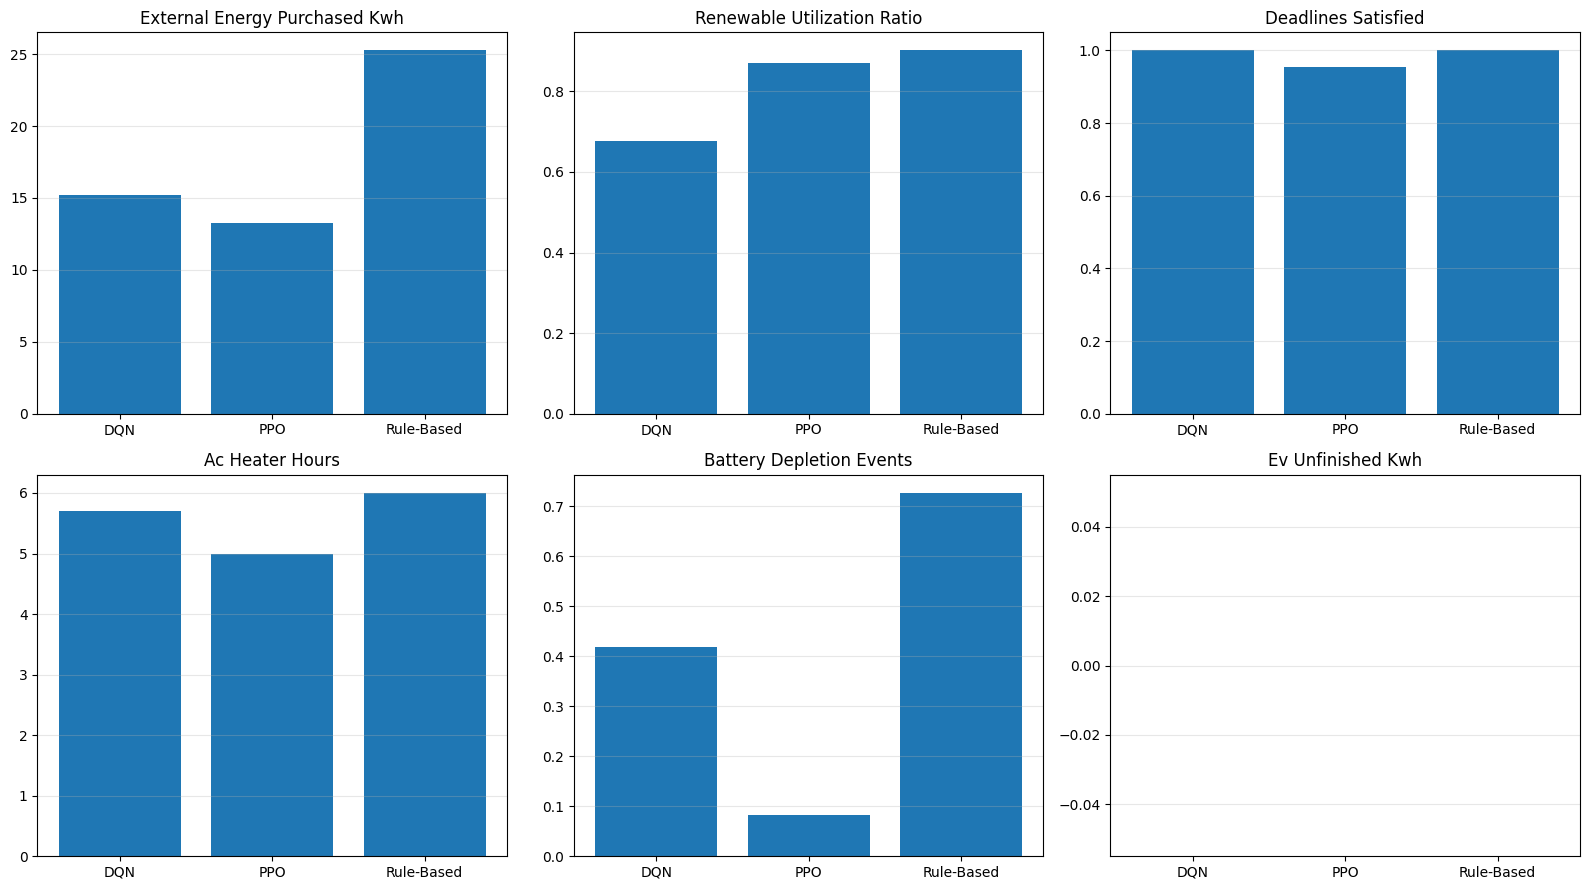


Figure saved:
- figure_4_1_model_comparison.png


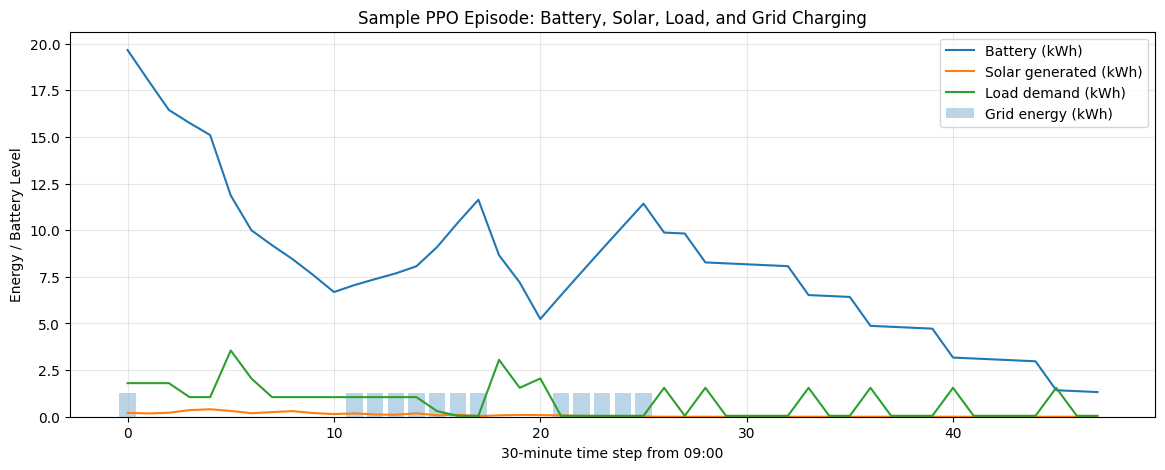


Figure saved:
- figure_4_2_ppo_episode.png

===== FINAL ARTEFACT OUTPUT CHECK =====
FOUND: supervisor_summary_table.csv
FOUND: supervisor_completion_rates.csv
FOUND: supervisor_all_test_results.csv
FOUND: figure_4_1_model_comparison.png
FOUND: figure_4_2_ppo_episode.png
FOUND: ppo_smart_home_model.zip
FOUND: dqn_smart_home_model.zip

DONE: Supervisor-aligned corrected code executed successfully.


In [4]:
!pip install -q gymnasium stable-baselines3 pandas matplotlib numpy

import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.monitor import Monitor

# ============================================================
# BASE ENVIRONMENT FOR PPO
# ============================================================

class SmartHomeEnv(gym.Env):
    """
    Supervisor-aligned environment:
    - solar -> battery -> appliances
    - grid -> battery -> appliances
    - 30-minute intervals
    - 09:00 to 22:00 daytime planning
    - EV can charge overnight
    - fixed-duration appliances continue automatically
    - reward includes grid cost, depletion, deadlines, EV completion, comfort
    """

    metadata = {"render_modes": []}

    def __init__(self, seed=None):
        super().__init__()

        self.rng = np.random.default_rng(seed)

        # Time
        self.dt = 0.5
        self.total_steps = 48
        self.day_end_step = 26

        # Energy system
        self.battery_capacity = 30.0
        self.initial_battery = 20.0
        self.solar_max_kw = 2.0
        self.grid_charge_kw = 2.5

        # Appliance powers
        self.fridge_kw = 0.1
        self.laundry_kw = 1.5
        self.dishwasher_kw = 1.0
        self.oven_kw = 2.0
        self.ac_kw = 3.0
        self.ev_kw = 2.0

        # Durations
        self.laundry_duration = 3
        self.dishwasher_duration = 3
        self.oven_duration = 2

        # Windows
        self.dishwasher_min_step = 18
        self.noon_window = (5, 11)
        self.evening_window = (18, 24)

        # Comfort
        self.ac_target_slots = 12

        # EV: total battery is 50 kWh, daily required charge is feasible within that capacity
        self.ev_total_capacity = 50.0
        self.ev_required_min = 8.0
        self.ev_required_max = 20.0

        # Solar coefficient: 5% resolution, minimum 10%
        self.coeff_values = np.round(np.arange(0.10, 1.05, 0.05), 2)

        # PPO action: simultaneous binary decisions
        # [laundry, dishwasher, oven, ac, ev, grid]
        self.action_space = spaces.MultiBinary(6)

        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(18,), dtype=np.float32
        )

    # --------------------------------------------------------
    # Solar model
    # --------------------------------------------------------
    def _max_solar_kw(self, step):
        if step >= self.day_end_step:
            return 0.0

        hour = 9.0 + step * self.dt
        peak_hour = 13.0
        sigma = 3.0

        bell = math.exp(-0.5 * ((hour - peak_hour) / sigma) ** 2)
        return self.solar_max_kw * bell

    def _sample_next_coeff(self):
        lower = max(0.10, self.solar_coeff - 0.20)
        upper = min(1.00, self.solar_coeff + 0.20)

        candidates = self.coeff_values[
            (self.coeff_values >= lower) & (self.coeff_values <= upper)
        ]

        return float(self.rng.choice(candidates))

    def _current_solar_kwh(self):
        return self._max_solar_kw(self.step_id) * self.solar_coeff * self.dt

    def _predicted_next_solar_kwh(self):
        next_step = min(self.step_id + 1, self.total_steps - 1)
        return self._max_solar_kw(next_step) * self.predicted_next_coeff * self.dt

    # --------------------------------------------------------
    # Time windows
    # --------------------------------------------------------
    def _is_daytime(self):
        return self.step_id < self.day_end_step

    def _is_noon_window(self):
        return self.noon_window[0] <= self.step_id < self.noon_window[1]

    def _is_evening_window(self):
        return self.evening_window[0] <= self.step_id < self.evening_window[1]

    # --------------------------------------------------------
    # Reset
    # --------------------------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.step_id = 0
        self.battery = self.initial_battery

        # Supervisor: initial coefficient at 09:00 = 50%
        self.solar_coeff = 0.50
        self.predicted_next_coeff = self._sample_next_coeff()

        # Running durations
        self.laundry_remaining = 0
        self.dishwasher_remaining = 0
        self.oven_remaining = 0
        self.oven_type = None

        # Task flags
        self.laundry_started = False
        self.laundry_done = False

        self.dishwasher_started = False
        self.dishwasher_done = False

        self.oven_noon_started = False
        self.oven_noon_done = False

        self.oven_evening_started = False
        self.oven_evening_done = False

        # EV demand
        self.ev_required = float(self.rng.uniform(self.ev_required_min, self.ev_required_max))
        self.ev_remaining = self.ev_required

        # Comfort
        self.ac_slots = 0

        # Metrics
        self.total_energy_used = 0.0
        self.external_energy_purchased = 0.0
        self.solar_generated = 0.0
        self.solar_used = 0.0
        self.battery_depletion_events = 0
        self.unserved_energy = 0.0

        self.trace = {
            "step": [],
            "battery": [],
            "solar_kwh": [],
            "load_kwh": [],
            "grid_kwh": [],
            "ac_on": [],
            "ev_on": []
        }

        return self._obs(), {}

    # --------------------------------------------------------
    # Observation
    # --------------------------------------------------------
    def _obs(self):
        return np.array([
            self.step_id / (self.total_steps - 1),
            self.battery / self.battery_capacity,
            self._predicted_next_solar_kwh() / (self.solar_max_kw * self.dt),
            self.solar_coeff,
            self.laundry_remaining / self.laundry_duration,
            float(self.laundry_done),
            self.dishwasher_remaining / self.dishwasher_duration,
            float(self.dishwasher_done),
            self.oven_remaining / self.oven_duration,
            float(self.oven_noon_done),
            float(self.oven_evening_done),
            self.ev_remaining / max(self.ev_required, 1e-6),
            min(1.0, self.ac_slots / self.ac_target_slots),
            float(self._is_daytime()),
            float(self._is_noon_window()),
            float(self._is_evening_window()),
            min(1.0, self.battery_depletion_events / 10.0),
            (self.total_steps - self.step_id) / self.total_steps
        ], dtype=np.float32)

    # --------------------------------------------------------
    # Step
    # --------------------------------------------------------
    def step(self, action):
        action = np.array(action).astype(int).tolist()
        start_laundry, start_dishwasher, start_oven, ac_on, ev_on, buy_grid = action

        reward = 0.0
        invalid_penalty = 0.0
        task_start_reward = 0.0
        task_completion_reward = 0.0

        # ----------------------------------------------------
        # Start fixed-duration appliances
        # ----------------------------------------------------
        if start_laundry:
            if (
                not self.laundry_started and
                self.laundry_remaining == 0 and
                self._is_daytime() and
                self.step_id <= self.day_end_step - self.laundry_duration
            ):
                self.laundry_started = True
                self.laundry_remaining = self.laundry_duration
                task_start_reward += 8.0
            else:
                invalid_penalty += 1.0

        if start_dishwasher:
            if (
                not self.dishwasher_started and
                self.dishwasher_remaining == 0 and
                self._is_daytime() and
                self.step_id >= self.dishwasher_min_step and
                self.step_id <= self.day_end_step - self.dishwasher_duration
            ):
                self.dishwasher_started = True
                self.dishwasher_remaining = self.dishwasher_duration
                task_start_reward += 8.0
            else:
                invalid_penalty += 1.0

        if start_oven:
            if self.oven_remaining == 0:
                if (
                    not self.oven_noon_started and
                    self._is_noon_window() and
                    self.step_id <= self.day_end_step - self.oven_duration
                ):
                    self.oven_noon_started = True
                    self.oven_remaining = self.oven_duration
                    self.oven_type = "noon"
                    task_start_reward += 8.0

                elif (
                    not self.oven_evening_started and
                    self._is_evening_window() and
                    self.step_id <= self.day_end_step - self.oven_duration
                ):
                    self.oven_evening_started = True
                    self.oven_remaining = self.oven_duration
                    self.oven_type = "evening"
                    task_start_reward += 8.0
                else:
                    invalid_penalty += 1.0
            else:
                invalid_penalty += 1.0

        # ----------------------------------------------------
        # Load calculation
        # ----------------------------------------------------
        load_kwh = self.fridge_kw * self.dt

        if self.laundry_remaining > 0:
            load_kwh += self.laundry_kw * self.dt

        if self.dishwasher_remaining > 0:
            load_kwh += self.dishwasher_kw * self.dt

        if self.oven_remaining > 0:
            load_kwh += self.oven_kw * self.dt

        if ac_on:
            load_kwh += self.ac_kw * self.dt
            self.ac_slots += 1
            reward += 2.5

        ev_energy_requested = 0.0
        if ev_on and self.ev_remaining > 0:
            ev_energy_requested = min(self.ev_kw * self.dt, self.ev_remaining)
            load_kwh += ev_energy_requested

        # ----------------------------------------------------
        # Energy flow: solar/grid charge battery
        # ----------------------------------------------------
        solar_kwh = self._current_solar_kwh()
        grid_kwh = self.grid_charge_kw * self.dt if buy_grid else 0.0

        self.solar_generated += solar_kwh
        self.external_energy_purchased += grid_kwh

        self.battery = min(
            self.battery_capacity,
            self.battery + solar_kwh + grid_kwh
        )

        # ----------------------------------------------------
        # Battery supplies appliances
        # ----------------------------------------------------
        served_kwh = min(self.battery, load_kwh)
        self.battery -= served_kwh

        unserved_kwh = max(0.0, load_kwh - served_kwh)

        if unserved_kwh > 1e-9:
            self.battery_depletion_events += 1
            self.unserved_energy += unserved_kwh
            reward -= 80.0 * unserved_kwh

        service_ratio = served_kwh / load_kwh if load_kwh > 0 else 1.0

        ev_delivered = ev_energy_requested * service_ratio
        self.ev_remaining = max(0.0, self.ev_remaining - ev_delivered)

        self.total_energy_used += load_kwh
        self.solar_used += min(solar_kwh, load_kwh)

        # Reward for useful EV charging
        reward += 3.0 * ev_delivered

        # Cost of external grid
        reward -= 2.0 * grid_kwh

        # Renewable use reward
        reward += 0.5 * min(solar_kwh, load_kwh)

        # Task start reward
        reward += task_start_reward

        # Invalid action penalty
        reward -= invalid_penalty

        # ----------------------------------------------------
        # Decrement running tasks and reward completion
        # ----------------------------------------------------
        if self.laundry_remaining > 0:
            self.laundry_remaining -= 1
            if self.laundry_remaining == 0:
                self.laundry_done = True
                task_completion_reward += 25.0

        if self.dishwasher_remaining > 0:
            self.dishwasher_remaining -= 1
            if self.dishwasher_remaining == 0:
                self.dishwasher_done = True
                task_completion_reward += 25.0

        if self.oven_remaining > 0:
            self.oven_remaining -= 1
            if self.oven_remaining == 0:
                if self.oven_type == "noon":
                    self.oven_noon_done = True
                    task_completion_reward += 25.0
                elif self.oven_type == "evening":
                    self.oven_evening_done = True
                    task_completion_reward += 25.0
                self.oven_type = None

        reward += task_completion_reward

        # ----------------------------------------------------
        # Trace
        # ----------------------------------------------------
        self.trace["step"].append(self.step_id)
        self.trace["battery"].append(self.battery)
        self.trace["solar_kwh"].append(solar_kwh)
        self.trace["load_kwh"].append(load_kwh)
        self.trace["grid_kwh"].append(grid_kwh)
        self.trace["ac_on"].append(ac_on)
        self.trace["ev_on"].append(ev_on)

        # ----------------------------------------------------
        # Advance time and solar coefficient
        # ----------------------------------------------------
        self.step_id += 1
        self.solar_coeff = self.predicted_next_coeff
        self.predicted_next_coeff = self._sample_next_coeff()

        terminated = self.step_id >= self.total_steps
        truncated = False

        if terminated:
            if not self.laundry_done:
                reward -= 80.0
            if not self.dishwasher_done:
                reward -= 80.0
            if not self.oven_noon_done:
                reward -= 80.0
            if not self.oven_evening_done:
                reward -= 80.0

            if self.ev_remaining > 0:
                reward -= 15.0 * self.ev_remaining
            else:
                reward += 40.0

            if self.ac_slots < self.ac_target_slots:
                reward -= 8.0 * (self.ac_target_slots - self.ac_slots)
            else:
                reward += 30.0

        info = self._final_metrics() if terminated else {}

        return (
            self._obs() if not terminated else np.zeros(self.observation_space.shape, dtype=np.float32),
            float(reward),
            terminated,
            truncated,
            info
        )

    def _final_metrics(self):
        deadlines_satisfied = int(
            self.laundry_done and
            self.dishwasher_done and
            self.oven_noon_done and
            self.oven_evening_done and
            self.ev_remaining <= 1e-6
        )

        return {
            "total_energy_used_kwh": self.total_energy_used,
            "external_energy_purchased_kwh": self.external_energy_purchased,
            "renewable_utilization_ratio": (
                self.solar_used / self.solar_generated if self.solar_generated > 0 else 0.0
            ),
            "deadlines_satisfied": deadlines_satisfied,
            "ac_heater_hours": self.ac_slots * self.dt,
            "battery_depletion_events": self.battery_depletion_events,
            "ev_unfinished_kwh": self.ev_remaining,
            "laundry_done": int(self.laundry_done),
            "dishwasher_done": int(self.dishwasher_done),
            "oven_noon_done": int(self.oven_noon_done),
            "oven_evening_done": int(self.oven_evening_done),
        }


# ============================================================
# DQN WRAPPER
# ============================================================

class SmartHomeDQNEnv(gym.Env):
    def __init__(self, seed=None):
        super().__init__()
        self.env = SmartHomeEnv(seed=seed)
        self.observation_space = self.env.observation_space
        self.action_space = spaces.Discrete(64)

    def reset(self, seed=None, options=None):
        return self.env.reset(seed=seed, options=options)

    def step(self, action):
        binary_action = np.array([(int(action) >> i) & 1 for i in range(6)], dtype=np.int8)
        return self.env.step(binary_action)


# ============================================================
# RULE-BASED BASELINE
# ============================================================

def run_rule_based(seed=None):
    env = SmartHomeEnv(seed=seed)
    obs, _ = env.reset(seed=seed)

    done = False

    while not done:
        action = np.zeros(6, dtype=np.int8)

        if not env.laundry_started and env._is_daytime():
            action[0] = 1

        if not env.oven_noon_started and env._is_noon_window():
            action[2] = 1

        if not env.dishwasher_started and env._is_evening_window():
            action[1] = 1

        if env.oven_noon_done and not env.oven_evening_started and env._is_evening_window():
            action[2] = 1

        if env.ev_remaining > 0:
            action[4] = 1

        if env.ac_slots < env.ac_target_slots:
            action[3] = 1

        if env.battery < 10.0:
            action[5] = 1

        obs, reward, done, truncated, info = env.step(action)

    return info, env


# ============================================================
# TRAINING
# ============================================================

PPO_TIMESTEPS = 120000
DQN_TIMESTEPS = 120000

print("Training PPO...")
ppo_env = Monitor(SmartHomeEnv(seed=42))
ppo_model = PPO(
    "MlpPolicy",
    ppo_env,
    verbose=0,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=64,
    gamma=0.99,
    ent_coef=0.02,
    seed=42
)
ppo_model.learn(total_timesteps=PPO_TIMESTEPS)

print("Training DQN...")
dqn_env = Monitor(SmartHomeDQNEnv(seed=43))
dqn_model = DQN(
    "MlpPolicy",
    dqn_env,
    verbose=0,
    learning_rate=1e-3,
    buffer_size=100000,
    learning_starts=5000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.35,
    exploration_final_eps=0.05,
    seed=43
)
dqn_model.learn(total_timesteps=DQN_TIMESTEPS)


# ============================================================
# EVALUATION
# ============================================================

def evaluate_ppo(model, n=1000):
    rows = []
    sample_env = None

    for i in range(n):
        env = SmartHomeEnv(seed=1000 + i)
        obs, _ = env.reset(seed=1000 + i)
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)

        rows.append(info)

        if i == 0:
            sample_env = env

    return pd.DataFrame(rows), sample_env


def evaluate_dqn(model, n=1000):
    rows = []
    sample_env = None

    for i in range(n):
        env = SmartHomeDQNEnv(seed=2000 + i)
        obs, _ = env.reset(seed=2000 + i)
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)

        rows.append(info)

        if i == 0:
            sample_env = env.env

    return pd.DataFrame(rows), sample_env


def evaluate_rule(n=1000):
    rows = []
    sample_env = None

    for i in range(n):
        info, env = run_rule_based(seed=3000 + i)
        rows.append(info)

        if i == 0:
            sample_env = env

    return pd.DataFrame(rows), sample_env


print("Evaluating on 1000 test cases...")
ppo_df, ppo_sample = evaluate_ppo(ppo_model)
dqn_df, dqn_sample = evaluate_dqn(dqn_model)
rule_df, rule_sample = evaluate_rule()

ppo_df["model"] = "PPO"
dqn_df["model"] = "DQN"
rule_df["model"] = "Rule-Based"

all_results = pd.concat([ppo_df, dqn_df, rule_df], ignore_index=True)

metrics = [
    "total_energy_used_kwh",
    "external_energy_purchased_kwh",
    "renewable_utilization_ratio",
    "deadlines_satisfied",
    "ac_heater_hours",
    "battery_depletion_events",
    "ev_unfinished_kwh"
]

summary = all_results.groupby("model")[metrics].agg(["mean", "std"]).round(4)
clean_summary = all_results.groupby("model")[metrics].agg(
    total_energy_used_kwh_mean=("total_energy_used_kwh", "mean"),
    total_energy_used_kwh_std=("total_energy_used_kwh", "std"),
    external_energy_purchased_kwh_mean=("external_energy_purchased_kwh", "mean"),
    external_energy_purchased_kwh_std=("external_energy_purchased_kwh", "std"),
    renewable_utilization_ratio_mean=("renewable_utilization_ratio", "mean"),
    renewable_utilization_ratio_std=("renewable_utilization_ratio", "std"),
    deadlines_satisfied_mean=("deadlines_satisfied", "mean"),
    deadlines_satisfied_std=("deadlines_satisfied", "std"),
    ac_heater_hours_mean=("ac_heater_hours", "mean"),
    ac_heater_hours_std=("ac_heater_hours", "std"),
    battery_depletion_events_mean=("battery_depletion_events", "mean"),
    battery_depletion_events_std=("battery_depletion_events", "std"),
    ev_unfinished_kwh_mean=("ev_unfinished_kwh", "mean"),
    ev_unfinished_kwh_std=("ev_unfinished_kwh", "std")
).round(4)

completion = all_results.groupby("model")[
    ["laundry_done", "dishwasher_done", "oven_noon_done", "oven_evening_done", "deadlines_satisfied"]
].mean().round(4)

print("\n===== SUPERVISOR-REQUESTED PERFORMANCE SUMMARY =====")
print(clean_summary)

print("\n===== TASK COMPLETION RATES =====")
print(completion)
# ============================================================
# SAVE RESULTS
# ============================================================

clean_summary.to_csv("supervisor_summary_table.csv")
completion.to_csv("supervisor_completion_rates.csv")
all_results.to_csv("supervisor_all_test_results.csv", index=False)

print("\nFiles saved:")
print("- supervisor_summary_table.csv")
print("- supervisor_completion_rates.csv")
print("- supervisor_all_test_results.csv")


# ============================================================
# SAVE TRAINED MODELS
# ============================================================

ppo_model.save("ppo_smart_home_model")
dqn_model.save("dqn_smart_home_model")

print("\nModels saved:")
print("- ppo_smart_home_model.zip")
print("- dqn_smart_home_model.zip")


# ============================================================
# FIGURE 4.1: MODEL COMPARISON
# ============================================================

mean_results = all_results.groupby("model")[metrics].mean().reset_index()

# Keep model order consistent with report
model_order = ["DQN", "PPO", "Rule-Based"]
mean_results["model"] = pd.Categorical(
    mean_results["model"],
    categories=model_order,
    ordered=True
)
mean_results = mean_results.sort_values("model")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_metrics = [
    "external_energy_purchased_kwh",
    "renewable_utilization_ratio",
    "deadlines_satisfied",
    "ac_heater_hours",
    "battery_depletion_events",
    "ev_unfinished_kwh"
]

plot_titles = [
    "External Energy Purchased Kwh",
    "Renewable Utilization Ratio",
    "Deadlines Satisfied",
    "Ac Heater Hours",
    "Battery Depletion Events",
    "Ev Unfinished Kwh"
]

for ax, metric, title in zip(axes.flatten(), plot_metrics, plot_titles):
    ax.bar(mean_results["model"], mean_results[metric])
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figure_4_1_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nFigure saved:")
print("- figure_4_1_model_comparison.png")


# ============================================================
# FIGURE 4.2: SAMPLE PPO EPISODE BEHAVIOUR
# ============================================================

trace = pd.DataFrame(ppo_sample.trace)

plt.figure(figsize=(14, 5))
plt.plot(trace["step"], trace["battery"], label="Battery (kWh)")
plt.plot(trace["step"], trace["solar_kwh"], label="Solar generated (kWh)")
plt.plot(trace["step"], trace["load_kwh"], label="Load demand (kWh)")
plt.bar(trace["step"], trace["grid_kwh"], alpha=0.3, label="Grid energy (kWh)")
plt.title("Sample PPO Episode: Battery, Solar, Load, and Grid Charging")
plt.xlabel("30-minute time step from 09:00")
plt.ylabel("Energy / Battery Level")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figure_4_2_ppo_episode.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nFigure saved:")
print("- figure_4_2_ppo_episode.png")


# ============================================================
# FINAL VERIFICATION OUTPUT
# ============================================================

print("\n===== FINAL ARTEFACT OUTPUT CHECK =====")

required_files = [
    "supervisor_summary_table.csv",
    "supervisor_completion_rates.csv",
    "supervisor_all_test_results.csv",
    "figure_4_1_model_comparison.png",
    "figure_4_2_ppo_episode.png",
    "ppo_smart_home_model.zip",
    "dqn_smart_home_model.zip"
]

for file in required_files:
    try:
        with open(file, "rb"):
            print(f"FOUND: {file}")
    except FileNotFoundError:
        print(f"MISSING: {file}")

print("\nDONE: Supervisor-aligned corrected code executed successfully.")